# Topological Data Analysis for Disease Subtypes

### In this notebook, we explore the endotypical geometry of a large language model for single cell RNA-seq data.

#### We compare the topology between diseases and observe finite differences

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

import os 
ENDOTYPE_DIR = "/media/lleger/LaCie/mit/disease_geometry/endotypes/"
print(os.listdir(ENDOTYPE_DIR))
endotype_results = pd.read_pickle("/media/lleger/LaCie/mit/disease_geometry/endotyping_results.pkl")
diseases = list(endotype_results.keys())
print(diseases, '\n', list(endotype_results[diseases[0]].keys()))

['normal_cells.h5ad', 'normal_embeddings.pkl', 'COVID-19_cells.h5ad', 'COVID-19_embeddings.pkl', 'glioblastoma_cells.h5ad', 'glioblastoma_embeddings.pkl', 'dementia_cells.h5ad', 'dementia_embeddings.pkl', 'lung adenocarcinoma_cells.h5ad', 'lung adenocarcinoma_embeddings.pkl', 'systemic lupus erythematosus_cells.h5ad', 'systemic lupus erythematosus_embeddings.pkl', 'dilated cardiomyopathy_cells.h5ad', 'dilated cardiomyopathy_embeddings.pkl', 'Crohn disease_cells.h5ad', 'Crohn disease_embeddings.pkl', 'clear cell renal carcinoma_cells.h5ad', 'clear cell renal carcinoma_embeddings.pkl', 'squamous cell lung carcinoma_cells.h5ad', 'squamous cell lung carcinoma_embeddings.pkl', 'nonpapillary renal cell carcinoma_cells.h5ad', 'nonpapillary renal cell carcinoma_embeddings.pkl', 'epilepsy_cells.h5ad', 'epilepsy_embeddings.pkl', 'breast cancer_cells.h5ad', 'breast cancer_embeddings.pkl', 'gastric cancer_cells.h5ad', 'gastric cancer_embeddings.pkl', 'non-small cell lung carcinoma_cells.h5ad', 'no

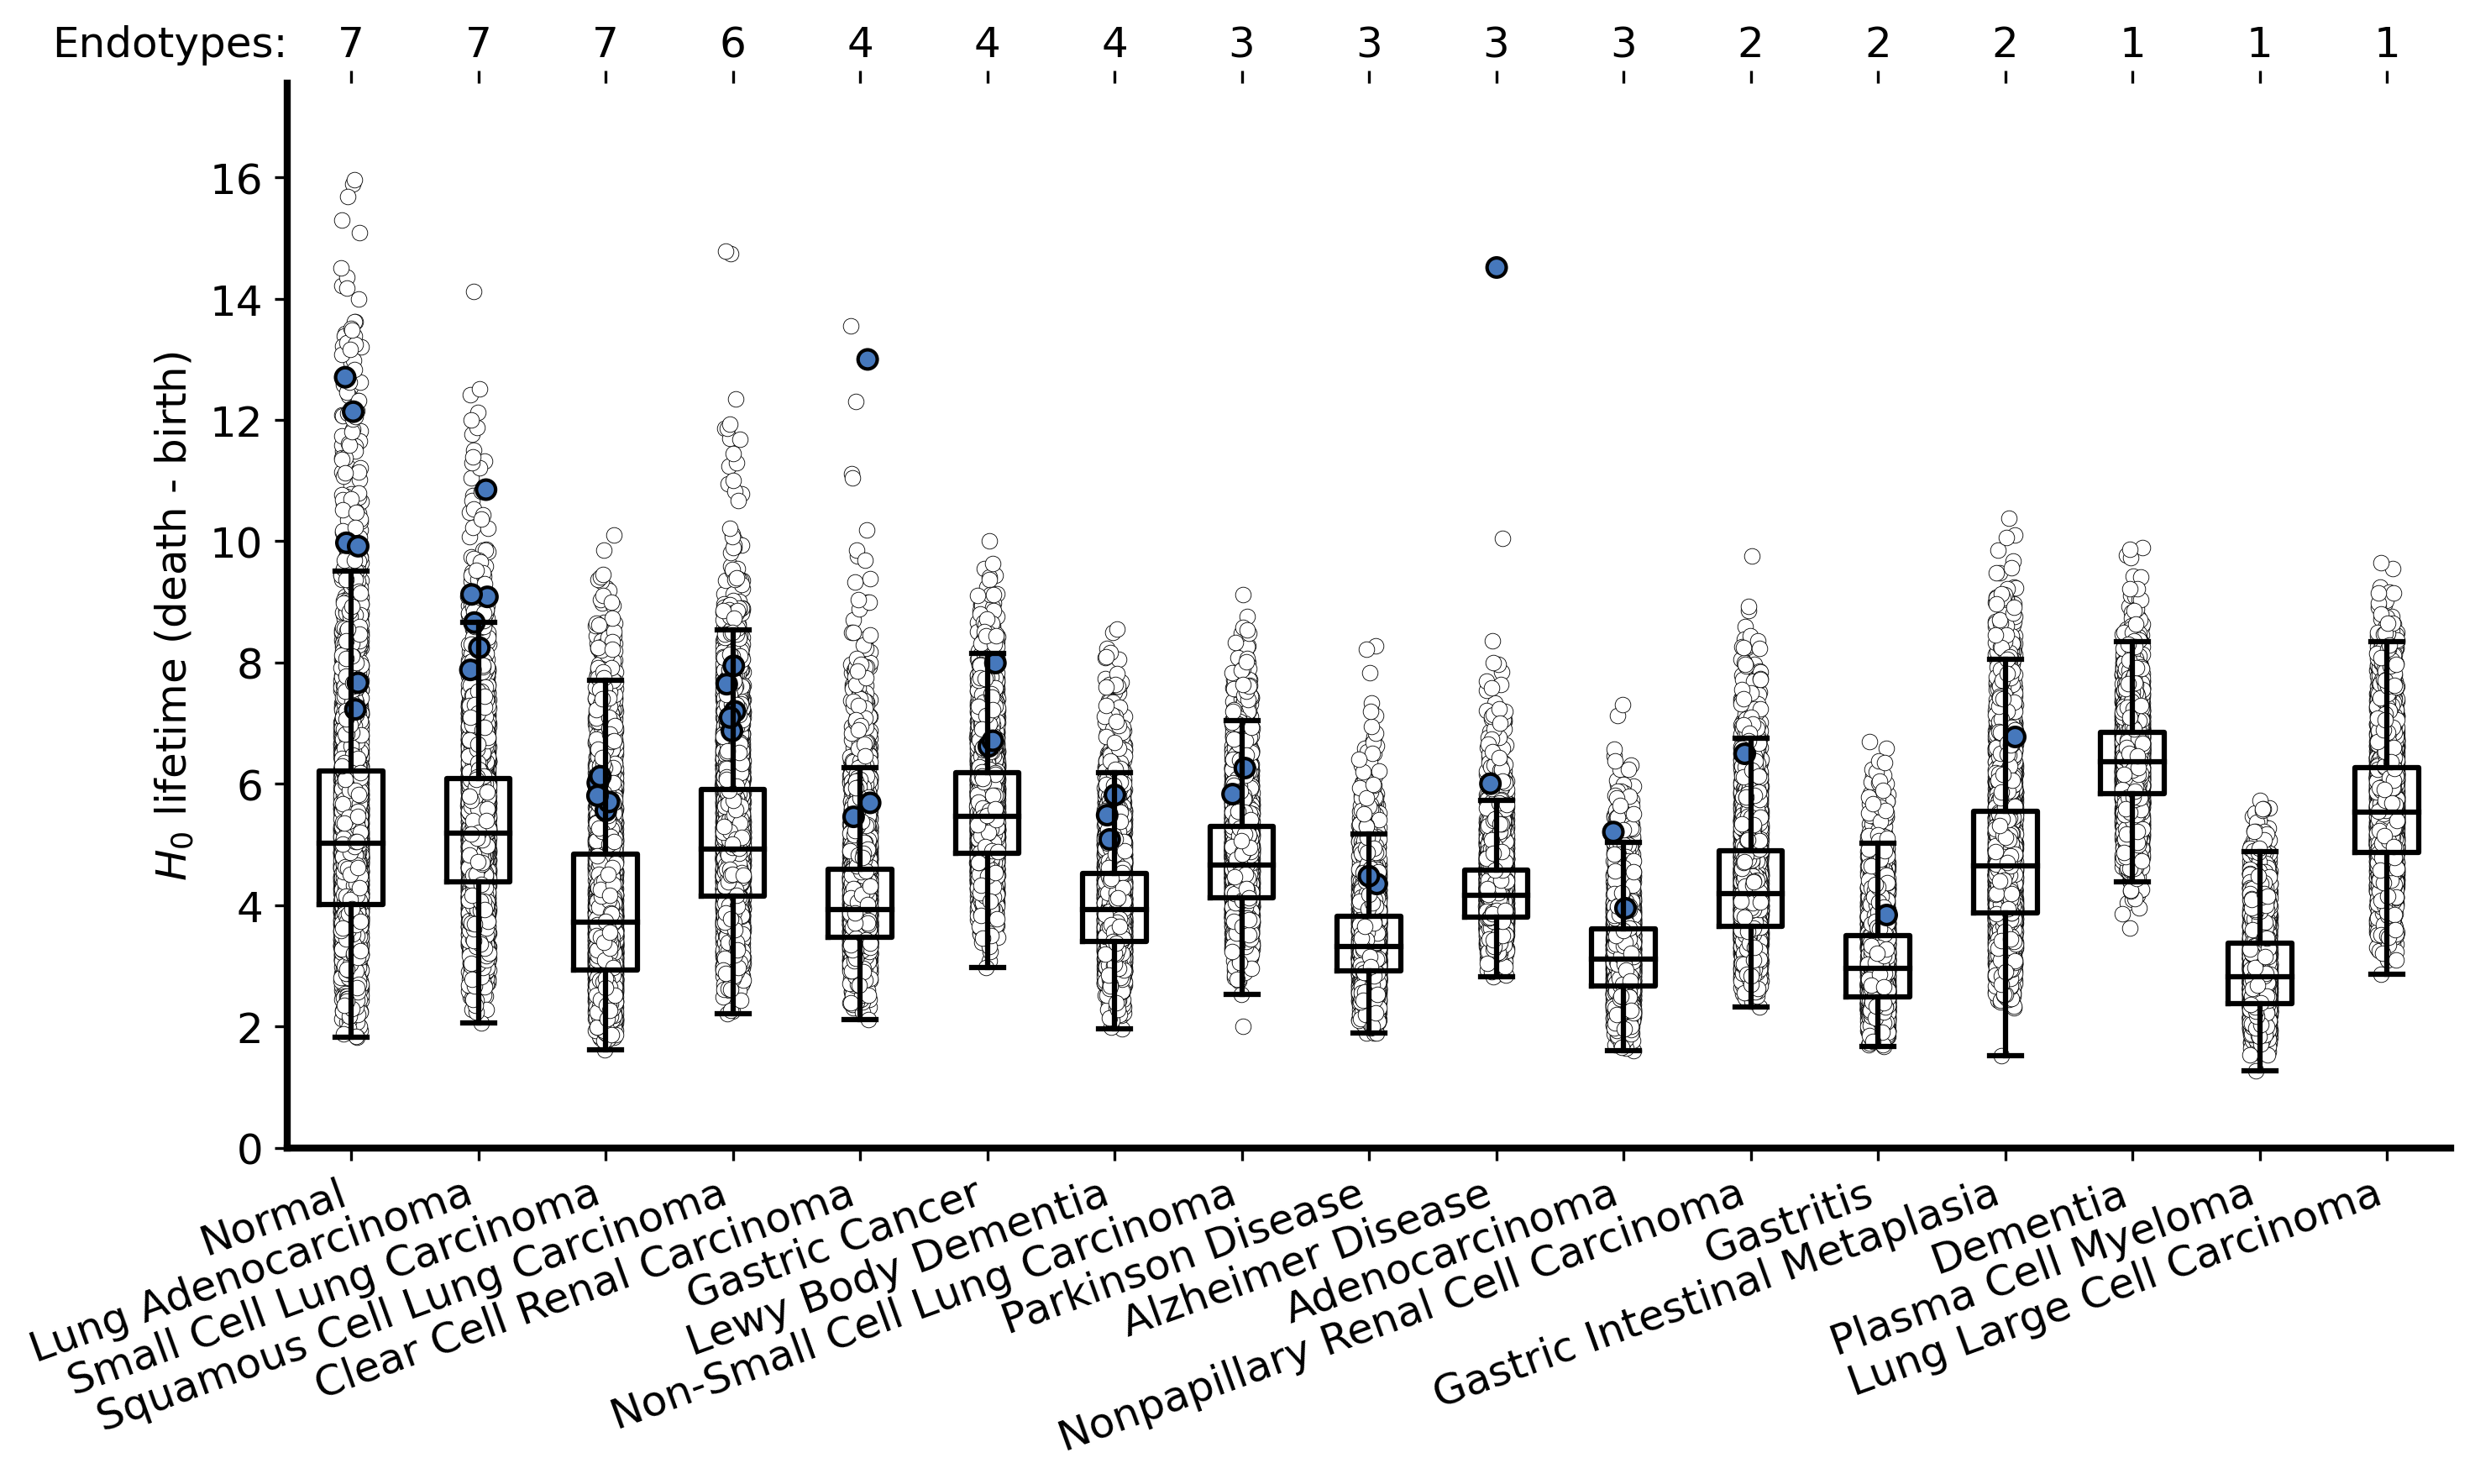

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_h0_boxplots_with_jitter_from_endotypes(
    endotype_results,
    diseases=None,
    figsize=(12, 6),
    fontsize=12,
    max_diseases=20,
    jitter=0.08,
    point_size=20,
    alpha=0.6,
    ):
    disease_selection = ('renal','gastr','park','dementia','alz','norm','plasma','carcino')
    diseases = [disease for disease in list(endotype_results.keys()) if not "raw" in disease and any(s in disease.lower() for s in disease_selection)][:max_diseases]
    lifetimes_list, masks_list  = [], []
    for d in diseases:
        res = endotype_results[d]["results"]
        lifetimes_list.append( res[:, 1][np.isfinite(res[:, 1])])
        masks_list.append(endotype_results[d]["corrected_endotype_mask"][np.isfinite(res[:, 1])])
    
    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    order = sorted(np.arange(len(lifetimes_list)), key=lambda x: masks_list[x].sum(), reverse=True)
    lifetimes_list = [lifetimes_list[idx] for idx in order]
    masks_list = [masks_list[idx] for idx in order]
    diseases = [diseases[idx] for idx in order]
    box = ax.boxplot(
        lifetimes_list,
        labels=diseases,
        showfliers=False,
        boxprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
        medianprops=dict(color="black", linewidth=1.5),
    )

    out_color = sns.color_palette("vlag", len(diseases))[0]

    endotype_counts = []
    for i, (lifetimes, mask) in enumerate(zip(lifetimes_list, masks_list), start=1):
        mask_in = ~mask & (lifetimes > 0)
        mask_out = mask & (lifetimes > 0)
        endotype_counts.append(mask_out.sum())

        xin = i + np.random.uniform(-jitter, jitter, mask_in.sum())
        xout = i + np.random.uniform(-jitter, jitter, mask_out.sum())

        ax.scatter(
            xin, lifetimes[mask_in],
            s=point_size, alpha=alpha,
            edgecolor="k", linewidth=0.2,
            c=['white']
        )

        ax.scatter(
            xout, lifetimes[mask_out],
            s=point_size * 1.5, alpha=1,
            edgecolor="k", linewidth=1,
            c=[out_color] * mask_out.sum(),
            label="Endotype" if i == 1 else None
        )

    ax.set_ylim(0, max([l.max() for l in lifetimes_list]) * 1.1)
    ax.text(0.5, ax.get_ylim()[1] + 0.3, f"Endotypes:", ha="right", va="bottom", fontsize=fontsize)
    for i, ecnt in enumerate(endotype_counts, start=1):
        ax.text(i, ax.get_ylim()[1] + 0.3, f"{ecnt+1}", ha="center", va="bottom", fontsize=fontsize)

    ax.set_ylabel("$H_0$ lifetime (death - birth)", fontsize=fontsize)
    ax.tick_params(axis="x", which="both", top=True, labeltop=False)
    labels = [tick.get_text().title() for tick in ax.get_xticklabels()]
    ax.set_xticklabels(labels)
    plt.xticks(rotation=20, ha='right', fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    [ax.spines[s].set_linewidth(0) for s in ['right','top']]
    [ax.spines[s].set_linewidth(2) for s in ['bottom','left']]
    #ax.set_title("Connected components ($H_0$) persistence (lifetime) per disease", y=1.08, fontsize=fontsize)
    plt.tight_layout()
    plt.savefig("../figures/figure3/number_of_stable_endotypes_per_disease.png", dpi=300,transparent=False)
    plt.show()

plot_h0_boxplots_with_jitter_from_endotypes(
    endotype_results,
    max_diseases=18,
    figsize=(10, 6),
    jitter=0.08,
    point_size=20,
    alpha=1.0,
    fontsize=12
)


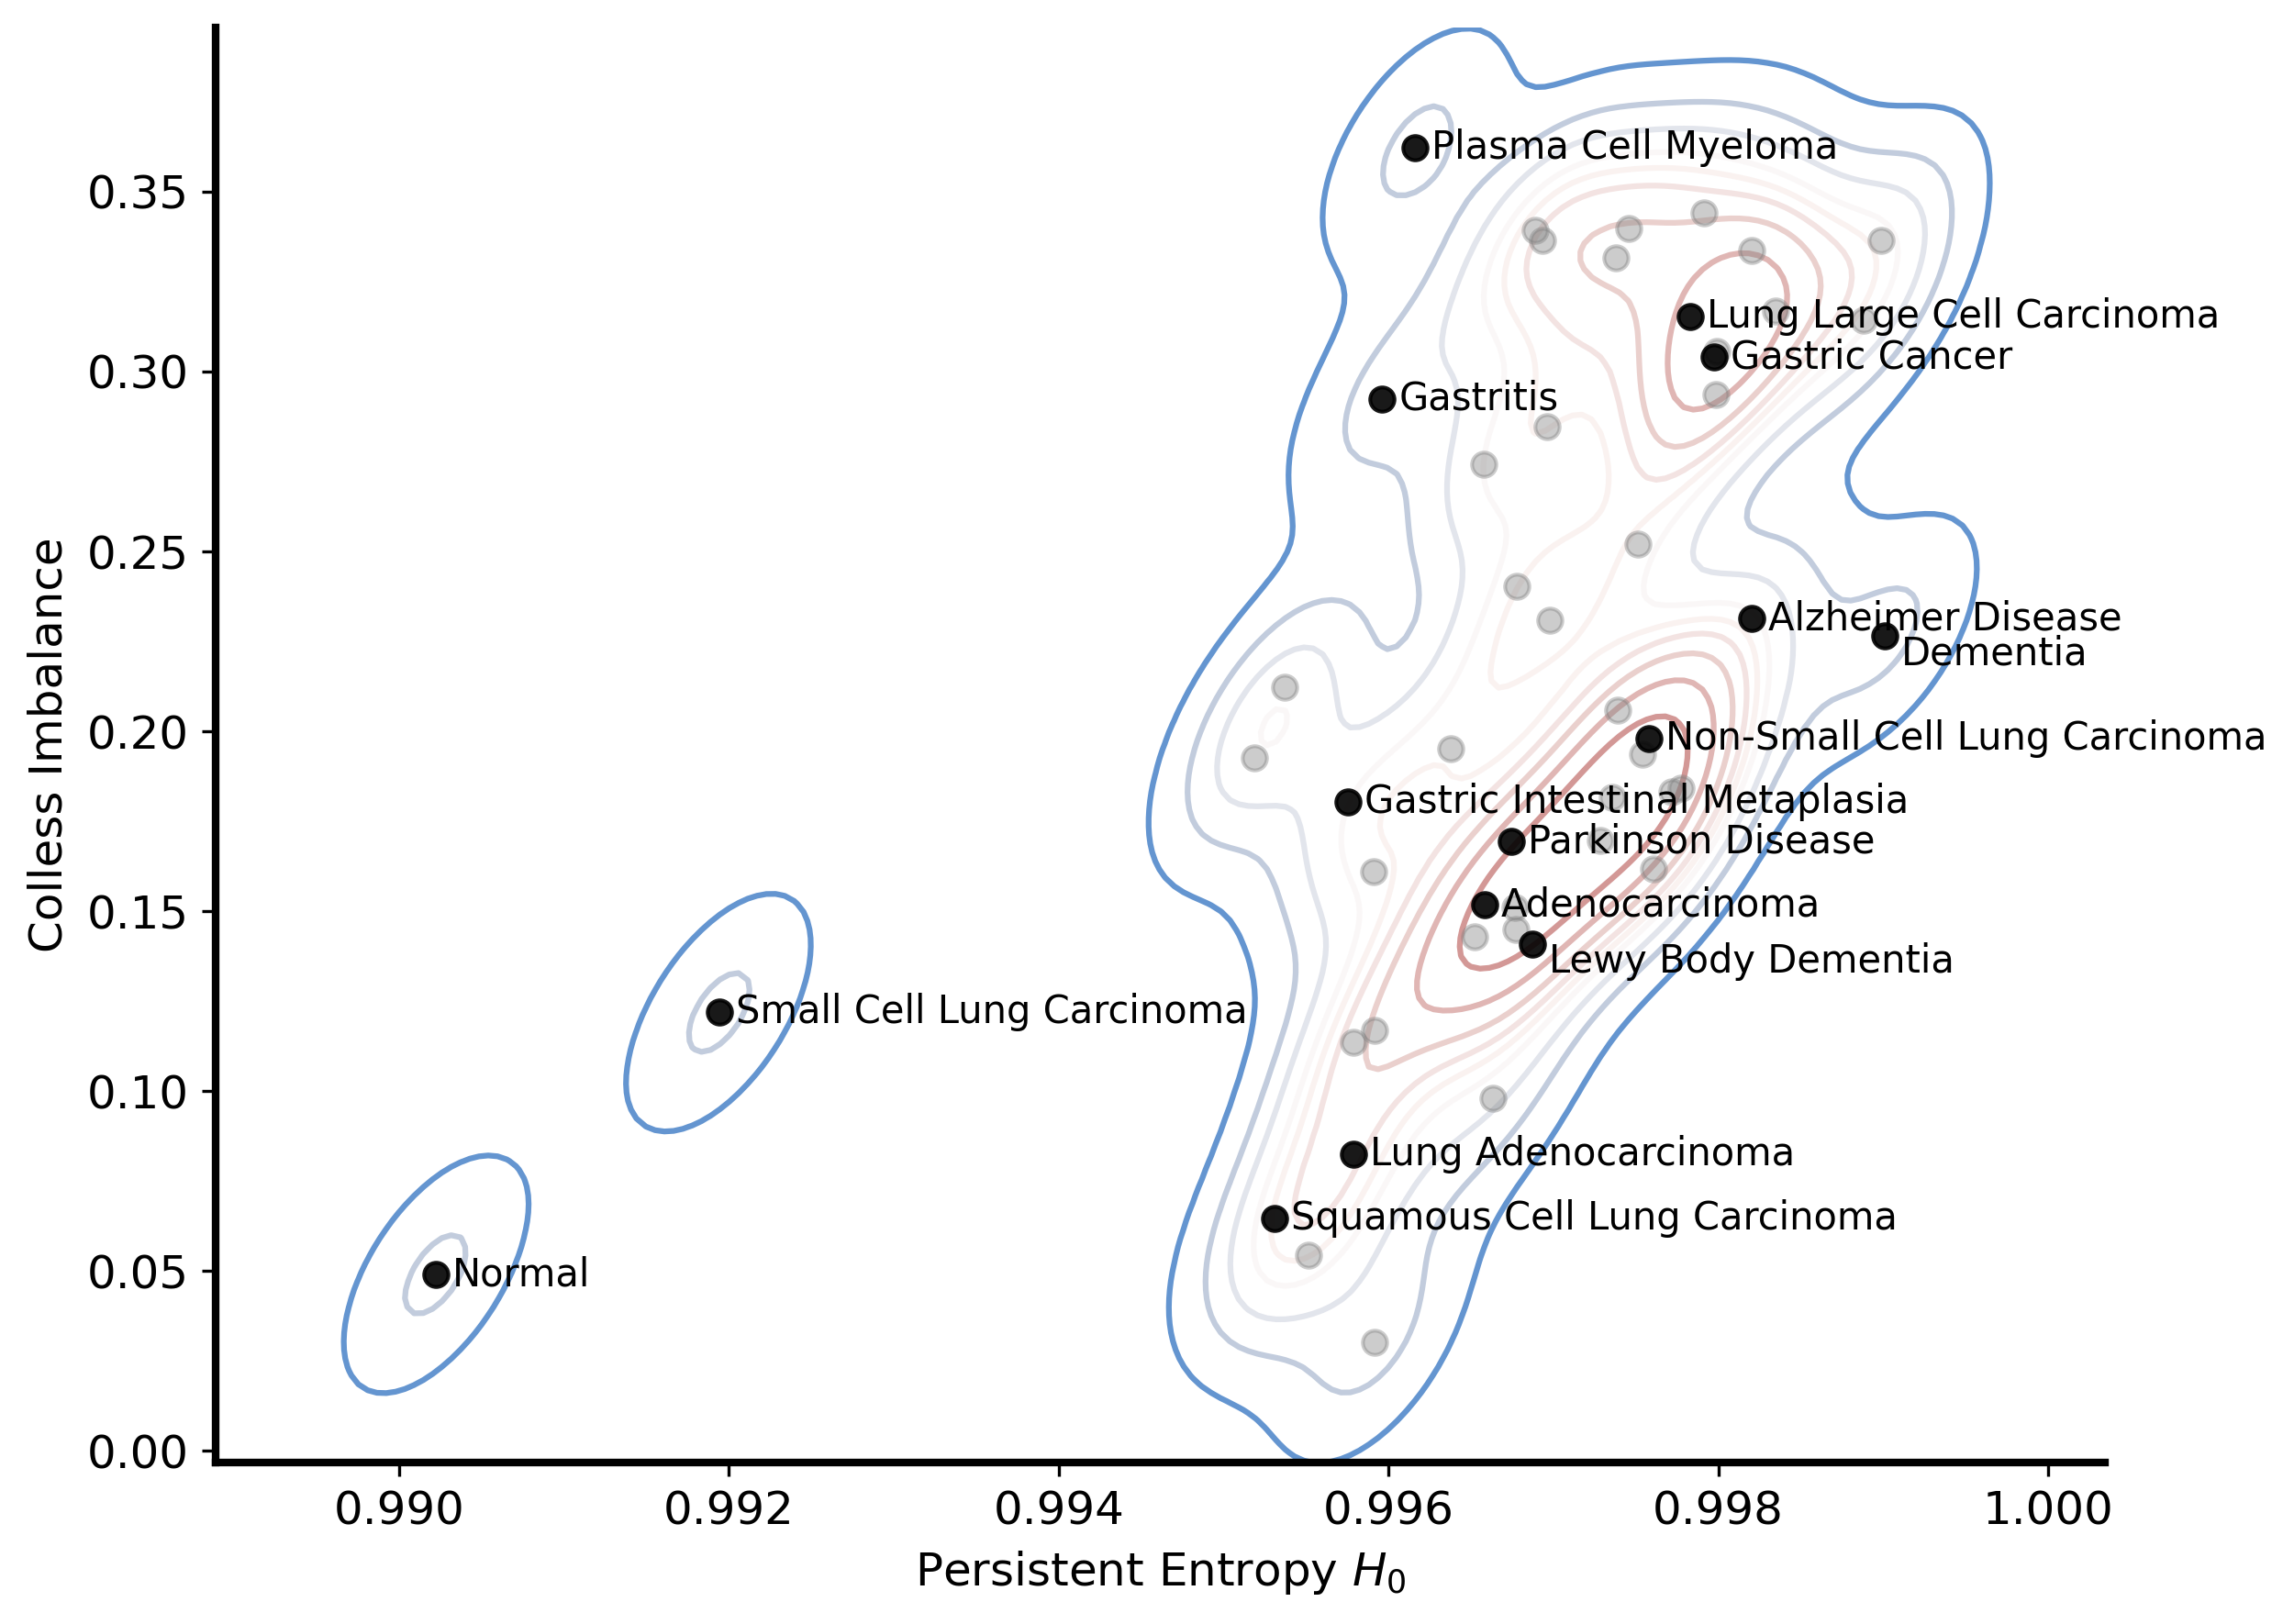

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import PowerNorm

fontsize = 12
dpi=300
df = pd.DataFrame({ disease: { "colless": result["bootstrap_colless"], "entropy": result["bootstrap_entropy"],}
    for disease, result in endotype_results.items() if not "raw" in disease}).T

metrics_df = pd.DataFrame({ "disease": df.index, "colless": df["colless"].values, "entropy": df["entropy"].values})
disease_selection = ('renal','gastr','park','dementia','alz','norm','plasma','carcino')
disease_selection = ('gastr','park','dementia','alz','norm','plasma','carci')
annotated = [disease for disease in list(endotype_results.keys()) if any(s in disease.lower() for s in disease_selection) and "renal" not in disease.lower()]

df_annotated = metrics_df[metrics_df["disease"].isin(annotated)].copy()
df_rest = metrics_df[~metrics_df["disease"].isin(annotated)]
df_annotated['disease'] = df_annotated['disease'].apply(lambda x: x.title())

plt.figure(figsize=(8.5,6), dpi=dpi)
sns.kdeplot( x=metrics_df["entropy"], y=metrics_df["colless"], levels=10, fill=False,
             cmap="vlag", alpha=.7, zorder=-1, bw_adjust=0.5, linewidths=1.5,   norm=PowerNorm(gamma=0.5))

plt.scatter(df_rest["entropy"], df_rest["colless"], s=40, alpha=0.4, color="grey", zorder=0)
plt.scatter(df_annotated["entropy"], df_annotated["colless"], s=40, alpha=0.9, color="k", zorder=1)

ax = plt.gca()
x_unit = np.diff(ax.get_xticks())[0]; y_unit = np.diff(ax.get_yticks())[0]
xlim = ( metrics_df["entropy"].min() - x_unit/1.5, metrics_df["entropy"].max() + x_unit/1.5)
ylim = ( metrics_df["colless"].min() - y_unit/3, metrics_df["colless"].max() + y_unit/3)
plt.xlim(xlim); plt.ylim(ylim)

for _, row in df_annotated.iterrows():
    yoffset = 0 if "Dem" not in row['disease'] else -y_unit/20
    plt.annotate(row["disease"], (row["entropy"] + x_unit/20, row["colless"]+yoffset), fontsize=fontsize-2, va="center", ha="left", fontweight='500'
    )
plt.xlabel("Persistent Entropy $H_0$", fontsize=fontsize)
plt.ylabel("Colless Imbalance", fontsize=fontsize)
plt.xticks(fontsize=fontsize); plt.yticks(fontsize=fontsize)

ax.spines[['left', 'bottom']].set_linewidth(2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/figure3/entropy_imbalance.png", dpi=dpi, transparent=False)
plt.savefig("../figures/figure3/entropy_imbalance.svg", dpi=dpi, transparent=True)
plt.show()

In [ ]:
print(diseases, '\n', list(endotype_results[diseases[0]].keys()))

['normal', 'normal_raw', 'COVID-19', 'COVID-19_raw', 'glioblastoma', 'glioblastoma_raw', 'dementia', 'dementia_raw', 'lung adenocarcinoma', 'lung adenocarcinoma_raw', 'systemic lupus erythematosus', 'systemic lupus erythematosus_raw', 'dilated cardiomyopathy', 'dilated cardiomyopathy_raw', 'Crohn disease', 'Crohn disease_raw', 'clear cell renal carcinoma', 'clear cell renal carcinoma_raw', 'squamous cell lung carcinoma', 'squamous cell lung carcinoma_raw', 'nonpapillary renal cell carcinoma', 'nonpapillary renal cell carcinoma_raw', 'epilepsy', 'epilepsy_raw', 'breast cancer', 'breast cancer_raw', 'gastric cancer', 'gastric cancer_raw', 'non-small cell lung carcinoma', 'non-small cell lung carcinoma_raw', 'arrhythmogenic right ventricular cardiomyopathy', 'arrhythmogenic right ventricular cardiomyopathy_raw', 'chronic kidney disease', 'chronic kidney disease_raw', 'acute kidney failure', 'acute kidney failure_raw', 'follicular lymphoma', 'follicular lymphoma_raw', 'myocardial infarctio

In [107]:
from matplotlib.collections import LineCollection
from scipy.spatial.distance import pdist, squareform
fontsize = 12
def vietoris_rips_complex(disease_endotypes, markersize, linewidth, alphaline, alphamarker, visual_epsilon, disease):
    # Identify connected components
    components = disease_endotypes['components']
    points_2d = disease_endotypes['umap_projection']
    epsilon = visual_epsilon
    
    top_genes = disease_endotypes['top_genes_per_component']
    distances = squareform(pdist(points_2d, metric="euclidean"))
    adjacency = {i: set(np.where(distances[i] < epsilon)[0]) - {i} for i in range(len(points_2d))}
    
    # Plot Vietoris-Rips Complex
    fig, ax = plt.subplots(figsize=(6,5.5), dpi=300)
    cmap = sns.color_palette("Paired", len(components))
    print("N components:", len(components), "Filtration epsilon:", epsilon)
    for idx, comp in enumerate(components):
        subcoords = points_2d[list(comp)]
        genes = top_genes[idx]
        ax.scatter(subcoords[:,0], subcoords[:,1], s=markersize, c=[cmap[idx]], alpha=alphamarker, label=f'{" / ".join(genes)}', linewidth=0)
        edges = [[points_2d[i], points_2d[j]] for i in comp for j in adjacency[i] if j in comp and i < j]
        lc = LineCollection(edges, colors=cmap[idx], linewidths=linewidth, alpha=alphaline)
        ax.add_collection(lc)
    
    all_component_indices = np.concatenate([list(c) for c in components])
    outlier_indices = np.setdiff1d(np.arange(len(points_2d)), all_component_indices)
    if len(outlier_indices) > 0:
        ax.scatter(points_2d[outlier_indices,0], points_2d[outlier_indices,1],  s=markersize, c='grey', alpha=0.3, label='Outliers', lw=0)

    ax.spines[['left', 'bottom']].set_linewidth(2); ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('UMAP1', fontsize=fontsize); ax.set_ylabel('UMAP2', fontsize=fontsize)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc='upper right',borderaxespad=0,fontsize=fontsize, frameon=True, facecolor='white', edgecolor='lightgrey', framealpha=0.4,
              title="Endotype",title_fontsize=fontsize,)     
    for legend_handle in ax.legend_.legendHandles:
        legend_handle.set_alpha(1)
        legend_handle.set_sizes([30])
    plt.title(f"{disease.title()} Vietoris-Rips Complex", fontsize=fontsize)
    plt.tight_layout()
    plt.savefig(f'../figures/figure3/{disease}_vietoris_rips.png', dpi=300, transparent=True)
    plt.close()

#for d in diseases:
for d in ['small cell lung carcinoma','glioblastoma',
           'Parkinson disease', 'lung large cell carcinoma',
             'Alzheimer disease', 'dilated cardiomyopathy', 'myocardial infarction']:
    vietoris_rips_complex(endotype_results[d], markersize=3, linewidth=0.2, alphaline=.3, alphamarker=0.2, visual_epsilon=1, disease=d)

N components: 7 Filtration epsilon: 1
N components: 7 Filtration epsilon: 1
N components: 3 Filtration epsilon: 1
N components: 1 Filtration epsilon: 1
N components: 3 Filtration epsilon: 1
N components: 2 Filtration epsilon: 1
N components: 1 Filtration epsilon: 1


In [108]:
# Barcode and persistence diagrams
from plot_utils import Barcode, plot_diagrams

fontsize=12
size=10
max_death = 15 # visual fix to normalize compare diagrams across diseases
colors = sns.color_palette("tab20c", 2)
colors = sns.color_palette("Paired", 2)
colors = [colors[0], (.1, .1, .1, 0.8)]
#for d in diseases:
for d in ['small cell lung carcinoma','glioblastoma',
           'Parkinson disease', 'lung large cell carcinoma',
             'Alzheimer disease', 'dilated cardiomyopathy', 'myocardial infarction']:
    print(d)
    fig, axes = plt.subplots(1, 1, figsize=(3, 3), dpi=500)
    ripser_result = endotype_results[d]['ripser_result']
    plot_diagrams(ripser_result, ax=axes, colors=colors, size=size, max_death=max_death)
    #axes.set_title(f"{d}", fontsize=fontsize)
    axes.legend(frameon=False, fontsize=fontsize)
    axes.set_xlabel('Birth',fontsize=fontsize)
    axes.set_ylabel('Death',fontsize=fontsize)
    axes.spines[['left', 'bottom']].set_linewidth(2); axes.spines[['top', 'right']].set_visible(False)

    for legend_handle in axes.legend_.legendHandles:
        legend_handle.set_alpha(1)
    plt.tight_layout()
    plt.savefig(f'../figures/figure3/{d}_persistence_diagram.png', dpi=500, transparent=True)
    plt.close()
    bc = Barcode(ripser_result)
    ax = bc.plot_barcode(figsize=(3,3), dpi=500, max_death=max_death)
    ax.set_xlabel('$H_0$ Component Death', fontsize=fontsize)
    ax.set_xlim(0, max_death+2)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontsize(fontsize)
    plt.tight_layout()
    plt.savefig(f'../figures/figure3/{d}_barcodes.png', dpi=500, transparent=True)
    plt.close()

small cell lung carcinoma
glioblastoma
Parkinson disease
lung large cell carcinoma
Alzheimer disease
dilated cardiomyopathy
myocardial infarction


In [43]:
print(list(endotype_results[diseases[0]].keys()))
for d in diseases:
    print(endotype_results[d]['stability_scores'])
    break

['outlier_mask', 'endotype_mask', 'results', 'corrected_endotype_mask', 'distance_matrix', 'components', 'stability_scores', 'stability_threshold', 'filtration_distance', 'filtration_size', 'persistent_entropy', 'colless_imbalance', 'bootstrap_entropy', 'bootstrap_colless', 'top_genes_per_component', 'ripser_result', 'umap_projection', 'points', 'confounder_results']
[0.32824679 0.34634747 0.35813541 0.35013004 0.25908652 0.20634876
 0.18814475]


/tmp/ipykernel_2124863/2532813987.py:12: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.3`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(data=confounder_dataframe, x="ami", y="confounder", inner="box", bw=0.3, linewidth=1.5, alpha=0.75, color=palette)


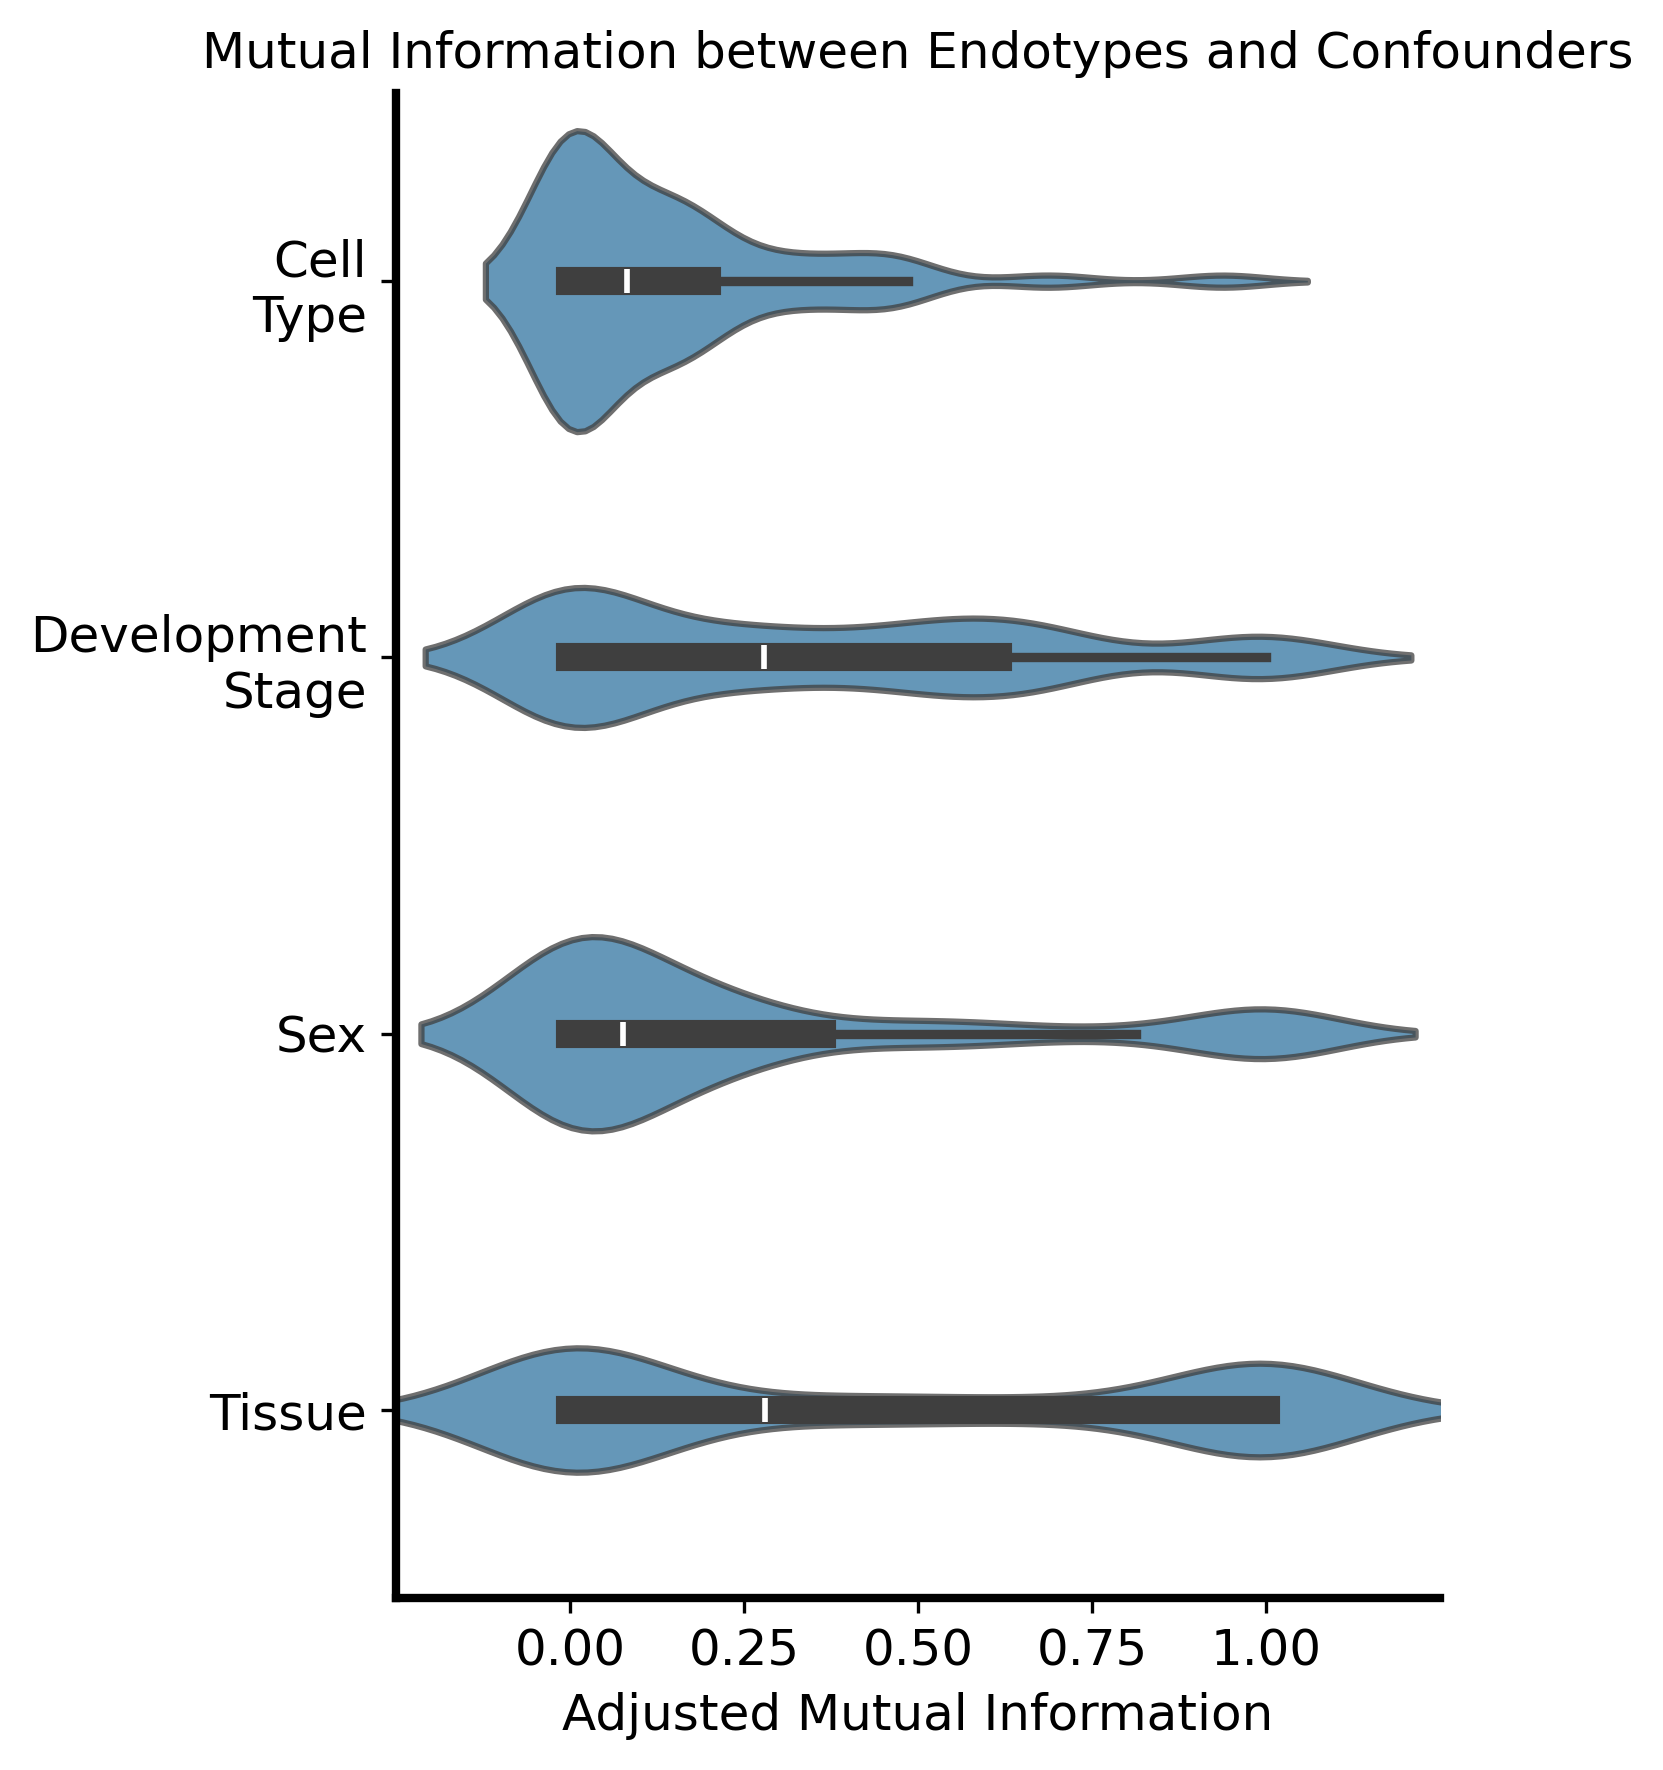

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

records = []
for disease, d in endotype_results.items():
    for confounder, v in d["confounder_results"].items():
        if disease == "normal" or "raw" in disease or confounder == "disease": continue
        records.append({"confounder": '\n'.join(confounder.split('_')).title(), "ami": v["ami"]})
confounder_dataframe = pd.DataFrame(records)

plt.figure(figsize=(5,4), dpi=300)
palette = sns.color_palette('Paired', n_colors=3)[1]
sns.violinplot(data=confounder_dataframe, x="ami", y="confounder", inner="box", bw=0.3, linewidth=1.5, alpha=0.75, color=palette)
plt.title("Mutual Information between Endotypes and Confounders", fontsize=fontsize)
plt.xlabel("Adjusted Mutual Information", fontsize=fontsize)
plt.ylabel("",)# fontsize=fontsize)
plt.xticks(rotation=0, fontsize=fontsize)
plt.xticks(np.arange(0, 1.25, step=0.25))
plt.xlim(-0.25, 1.25)
plt.yticks(fontsize=fontsize)

ax = plt.gca()
ax.spines[['left','bottom']].set_linewidth(2)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/figure3/mutual_information_endotypes_confounders.svg", dpi=300, transparent=True)
plt.savefig("../figures/figure3/mutual_information_endotypes_confounders.png", dpi=300, transparent=False)
plt.show()

      group     value       std
0     scRNA  0.251491  0.382822
1  PolyGene  0.504062  0.401903


/tmp/ipykernel_2124863/3412094609.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="group", y="value", palette=palette,


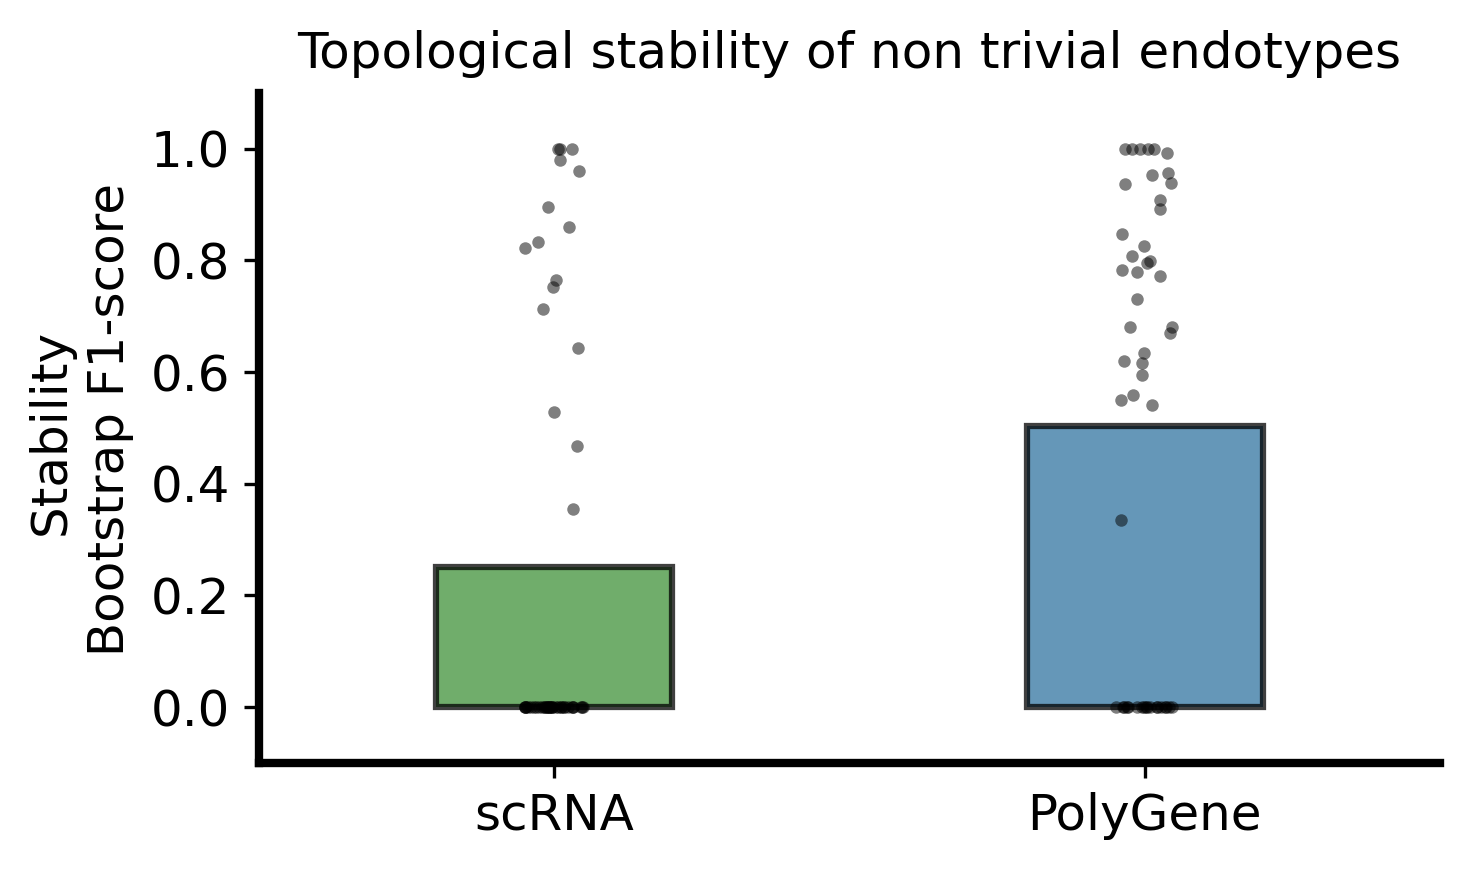

In [105]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

raw_values = []
model_values = []

fontsize=12
sampling_fraction = 0.33

for disease, d in endotype_results.items():
    scores = np.sort(np.array(d["stability_scores"]))[::-1]
    if len(scores) <= 1:
        avg = 0
    else:
        avg = scores[1:].mean()
    norm_avg = min(avg / sampling_fraction, 1)
    
    if "raw" in disease: raw_values.append(norm_avg)
    else: model_values.append(norm_avg)
plot_df = pd.DataFrame({
    "group": ["scRNA", "PolyGene"],
    "value": [np.mean(raw_values), np.mean(model_values)]
})
plot_df["std"] = [np.std(raw_values), np.std(model_values)]
print(plot_df)

plt.figure(figsize=(5,3), dpi=300)
palette = [sns.color_palette('Paired')[3], sns.color_palette('Paired')[1]]

sns.barplot(data=plot_df, x="group", y="value", palette=palette,
            edgecolor="k", width=0.4, alpha=0.75, linewidth=1.5,
            errorbar=None)

#plt.errorbar(x=[0,1], y=plot_df["value"], yerr=plot_df["std"],
#             fmt="none", ecolor="k", capsize=5, lw=1.5, zorder=10)

sns.stripplot(data=pd.DataFrame({"group":["scRNA"]*len(raw_values)+["PolyGene"]*len(model_values),
                                 "value":raw_values+model_values}),
              x="group", y="value", color="k", size=3, jitter=0.05, zorder=5, alpha=0.5)

plt.ylabel("Stability \n Bootstrap F1-score", fontsize=fontsize)
plt.xlabel("")
plt.title("Topological stability of non trivial endotypes", fontsize=fontsize)
plt.xticks(fontsize=fontsize)#, rotation=20, ha="right")
plt.yticks(fontsize=fontsize)

plt.ylim(-0.1, 1.1)
ax = plt.gca()
ax.spines[['left','bottom']].set_linewidth(2)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/figure3/topological_stability.svg", dpi=300, transparent=True)
plt.savefig("../figures/figure3/topological_stability.png", dpi=300, transparent=False)
plt.show()
